Pada bagian ini Kami mengupload file kaggle.json yang berisi API key dari Kaggle untuk mengakses dataset secara langsung dari Kaggle.

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"ercenttannius","key":"84f8198c294490fd45ab7d1d088e8ad5"}'}

Kemudian dilakukan konfigurasi Kaggle API dengan membuat folder .kaggle, menyalin file API key, dan mengatur permission agar dapat digunakan dengan aman.

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API siap!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle API siap!


Dataset diunduh langsung dari Kaggle menggunakan API, yaitu dataset PlantVillage yang berisi gambar daun dengan berbagai jenis penyakit

In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
print("✅ Download selesai!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:08<00:00, 249MB/s]

✅ Download selesai!


Setelah diunduh, dataset diekstrak ke dalam folder /content/dataset agar dapat digunakan dalam proses training.

In [ ]:
!unzip plantvillage-dataset.zip -d /content/dataset
print("✅ Extract selesai!")

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e37e8ad-3944-4e11-bc10-dd82616274d7___YLCV_NREC 2915_final_masked.jpg  
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e382244-fb3a-4caa-af71-05fff25f1c27___UF.GRC_YLCV_Lab 03397_final_masked.jpg  
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e3b9886-ce13-49d5-8f80-ccf4e5ddbeac___YLCV_GCREC 5479_final_masked.jpg  
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e615038-7a87-446a-a2cd-f76c5c75b6dd___YLCV_GCREC 5144_final_masked.jpg  
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e6938d9-1ab0-4728-993c-1069b66ce73b___UF.GRC_YLCV_Lab 02727_final_masked.jpg  
  inflating: /content/dataset/plantvillage dataset/segmented/Tomato_

Pada bagian ini, Kami membuat fungsi untuk mengeksplorasi struktur dataset menggunakan os.walk.
Tujuannya adalah untuk memahami bagaimana data disusun sebelum digunakan untuk training.

In [ ]:
import os

dataset_path = '/content/dataset'
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:3]:
            print(f"{indent}  {f}")

dataset/
  plantvillage dataset/
    color/
      Corn_(maize)___Common_rust_/
      Grape___Leaf_blight_(Isariopsis_Leaf_Spot)/
      Strawberry___Leaf_scorch/
      Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot/
      Orange___Haunglongbing_(Citrus_greening)/
      Tomato___Target_Spot/
      Grape___healthy/
      Tomato___Leaf_Mold/
      Cherry_(including_sour)___healthy/
      Tomato___Tomato_mosaic_virus/
      Squash___Powdery_mildew/
      Strawberry___healthy/
      Tomato___Tomato_Yellow_Leaf_Curl_Virus/
      Corn_(maize)___healthy/
      Tomato___Bacterial_spot/
      Soybean___healthy/
      Tomato___Spider_mites Two-spotted_spider_mite/
      Tomato___Septoria_leaf_spot/
      Tomato___Early_blight/
      Grape___Esca_(Black_Measles)/
      Peach___healthy/
      Apple___Apple_scab/
      Apple___Black_rot/
      Grape___Black_rot/
      Potato___healthy/
      Blueberry___healthy/
      Apple___healthy/
      Potato___Late_blight/
      Pepper,_bell___Bacterial_spo

Lanjutan Yang Atas
Dari hasil ini, terlihat bahwa dataset memiliki beberapa folder utama seperti grayscale, color, dan segmented.

Setiap folder berisi subfolder yang merepresentasikan kelas, misalnya jenis tanaman dan penyakit seperti Tomato Early Blight atau Apple Healthy.

Pada project ini, Kami memilih menggunakan data dari folder color karena memiliki informasi visual yang lebih lengkap dibandingkan grayscale.


Di sini Kami menginstall library timm, yang digunakan untuk mengakses berbagai model pretrained dalam Computer Vision.

In [ ]:
!pip install timm -q

Kemudian Kami mengimport library yang dibutuhkan seperti PyTorch untuk membangun model, torchvision untuk pengolahan gambar, dan sklearn untuk evaluasi model.

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from tqdm import tqdm

Pada bagian ini Kami mendefinisikan parameter training seperti batch size, jumlah epoch, learning rate, dan ukuran gambar yang akan digunakan sebagai input model.
Sama disini kami menentukan device yang dipake yaitu pake gpu(Cuda) ini akan lebih cepat dibanding CPU

In [ ]:
path = "/content/dataset" # change path
BATCH_SIZE = 32
EPOCHS = 15
LR = 0.0001
IMG_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Pada bagian ini, saya menentukan path dataset yang digunakan, yaitu folder color dari PlantVillage. Kemudian saya menampilkan daftar kelas yang tersedia, di mana setiap folder merepresentasikan jenis tanaman dan penyakitnya.(Data_Root),Dari outputnya terlihat banyak kelas misal Raspeberry_helathy dll.

Selanjutnya dilakukan preprocessing dan data augmentation. Gambar di-resize agar seragam, lalu dilakukan augmentasi seperti flipping, rotation, dan color jitter untuk menambah variasi data dan meningkatkan kemampuan generalisasi model. (Ini pada bagian train transform)

Untuk data validation, hanya dilakukan resize tanpa augmentasi agar evaluasi model lebih objektif. Ini Pada val_transforms

Dataset dimuat menggunakan ImageFolder, yang secara otomatis membaca label berdasarkan nama folder (full_dataset)

setelah itu dataset dibagi menjadi training dan validation dengan rasio 80 : 20 untuk melatih modelnya

DataLoader digunakan untuk membagi data ke dalam batch agar proses training lebih efisien dan dapat dilakukan secara Berulang.

In [ ]:
import os
from torchvision import datasets
from torch.utils.data import DataLoader

# The path based on your specific 'color' subdirectory find
data_root = "/content/dataset/plantvillage dataset/color"
# Verify the contents—you should see folder names like 'Apple___Apple_scab', etc.
print("Actual classes found:", os.listdir(data_root))
#transormasi -> ini yang ada dimateri compvis
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Load the dataset
# Note: If this folder contains the classes directly (no 'train'/'val' split),
# you'll need to manually split the dataset.
full_dataset = datasets.ImageFolder(root=data_root, transform=train_transforms)

# Example: 80/20 Split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total images: {len(full_dataset)}")

Actual classes found: ['Corn_(maize)___Common_rust_', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Strawberry___Leaf_scorch', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Orange___Haunglongbing_(Citrus_greening)', 'Tomato___Target_Spot', 'Grape___healthy', 'Tomato___Leaf_Mold', 'Cherry_(including_sour)___healthy', 'Tomato___Tomato_mosaic_virus', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Corn_(maize)___healthy', 'Tomato___Bacterial_spot', 'Soybean___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Septoria_leaf_spot', 'Tomato___Early_blight', 'Grape___Esca_(Black_Measles)', 'Peach___healthy', 'Apple___Apple_scab', 'Apple___Black_rot', 'Grape___Black_rot', 'Potato___healthy', 'Blueberry___healthy', 'Apple___healthy', 'Potato___Late_blight', 'Pepper,_bell___Bacterial_spot', 'Peach___Bacterial_spot', 'Tomato___healthy', 'Pepper,_bell___healthy', 'Raspberry___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 

Di sini Kami cuma ngecek apakah folder dataset sudah terbaca dengan benar.

In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    break

/content/dataset


menampilkan isi folder dataset di Colab

In [ ]:
!ls /content/dataset

'plantvillage dataset'


menampilkan isi folder “plantvillage dataset”

In [ ]:
!ls "/content/dataset/plantvillage dataset"

color  grayscale  segmented


Pada bagian ini, dataset dimuat menggunakan ImageFolder, di mana label otomatis diambil dari nama folder kelas (full_dataset)

Dataset kemudian dibagi menjadi data training dan validation dengan rasio 80:20 untuk melatih dan mengevaluasi model.

Setelah split, saya mengganti transform pada data validation agar tidak menggunakan augmentasi, sehingga evaluasi model tetap objektif (Pada Val_dataset)

DataLoader digunakan untuk membagi data ke dalam batch agar proses training lebih efisien

In [ ]:
from torch.utils.data import random_split

DATA_DIR = "/content/dataset/plantvillage dataset/color"

full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)

# 80-20 split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply validation transform separately
val_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

num_classes = len(full_dataset.classes)
print("Classes:", full_dataset.classes)

Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___

Pada bagian ini, Kami menggunakan model EfficientNet-B0 dari library timm dengan pretrained weights, sehingga model sudah memiliki pengetahuan awal dari dataset besar seperti ImageNet.

Layer terakhir pada model diganti agar sesuai dengan jumlah kelas pada dataset saya, sehingga model dapat melakukan klasifikasi sesuai dengan jumlah penyakit tanaman

Model dijalankan dalam model GPU

In [ ]:
model = timm.create_model("efficientnet_b0", pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Pada bagian ini, saya menggunakan CrossEntropyLoss sebagai fungsi loss untuk mengukur seberapa besar kesalahan prediksi model terhadap label sebenarnya

Saya menggunakan optimizer Adam untuk mengupdate bobot model selama training, dengan learning rate sebesar 0.0001 agar proses pembelajaran berjalan stabil

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

Fungsi ini digunakan untuk melatih model selama satu epoch, yaitu satu kali proses terhadap seluruh data training. (Def train_epoch)

Model diatur ke mode training agar layer seperti dropout dan batch normalization bekerja sesuai kebutuhan training. (Model.train) , Kemudian ada inisialisasi 3 variabel untuk nyimpen total loss sama dia hitung akurasi selama dia di train

Untuk for images,labels itu Data diambil per batch dari DataLoader untuk diproses secara bertahap.,Lalu ada images.to device itu kami pindahin ke GPU biar bisa lebih cepat.

Setelah itu ada optimizer itu untuk Gradient di-reset agar tidak menumpuk dari iterasi sebelumnya,yang outputs itu dia prediksi sesuai gambar,lalu ada loss itu untuk menghitung kesalahan prediksi modelnya,sama loss backward itu backpropogation utk hitung gradient dari loss dan yang terakhir optimizer step itu dia perbarui bobotnya

Selanjutnya itu ada predicted itu untuk prediksi kelas diambil dari nilai tertinggi,kemudian yang correct itu untuk menghitung jumlah prediksi yang benar

In [ ]:
def train_one_epoch():
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    return running_loss/len(train_loader), accuracy

Fungsi validate itu digunakan untuk evaluasi performa,kemudian Model diubah ke mode evaluasi agar layer seperti dropout dan batch normalization tidak aktif seperti saat training,inisilasi variabel kayak sebelumnya untuk hitung loss dan akurasi,kemudian yang allpreds dikasih [], alllabels itu untuk nyimpen hasil prediksi dan label asli

Selanjutnya itu ada nograd itu pada validasi,gradient tidak dihitung,karena model tidak lagi belajar,habis itu ada for images ,labels itu dia diproses per batch pake dataloader

untuk yang outputs itu dia prediksi terhadap data validationnya,lalu ada loss lagi dia mengukur performa modelnya,Lalu yang predicted dia ambil kelas prediksi dari nilai yang tertinggi,lalu di correct dia itung jumlah prediksi yang benar,allpreds dan alllabels itu prediksi dan label disimpan

In [ ]:
def validate():
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100. * correct / total
    return running_loss/len(val_loader), accuracy, all_preds, all_labels

Pada Bagian bestacc ini diinisialisasi untuk menyimpan akurasi terbaik,serta parameter early stopping yaitu patience ,trigger.
Setelah ini ada yang for epoch itu untuk melatih model dengan beberapa epoch,Selanjutnya pada proses epoch dilakukan training dan validation untuk lihat performa modelnya.

untuk yang jika vall acc lebih besar dari best acc itu jika akurasi val naik ,dia disimpan jadi model terbaik.lalu pada torch save itu model disimpan agar bisa digunakan kembali.sama yang terakhir jika tidak ada peningkatan pas beberapa epoch itu langsung lakukan percepatan stop,biar gak overfitting.

In [ ]:
best_acc = 0
patience = 3
trigger = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc, preds, labels = validate()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "efficientnet_plant_best.pth")
        print("✅ Model Saved!")
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            print("⛔ Early Stopping Triggered")
            break


Epoch 1/15


100%|██████████| 1358/1358 [05:18<00:00,  4.27it/s]


Train Loss: 0.3171 | Train Acc: 93.09%
Val Loss: 0.0253 | Val Acc: 99.27%
✅ Model Saved!

Epoch 2/15


100%|██████████| 1358/1358 [05:13<00:00,  4.34it/s]


Train Loss: 0.0296 | Train Acc: 99.14%
Val Loss: 0.0186 | Val Acc: 99.49%
✅ Model Saved!

Epoch 3/15


...

Train Loss: 0.0052 | Train Acc: 99.84%
Val Loss: 0.0123 | Val Acc: 99.59%

Epoch 11/15


100%|██████████| 1358/1358 [05:12<00:00,  4.34it/s]


Train Loss: 0.0061 | Train Acc: 99.82%
Val Loss: 0.0112 | Val Acc: 99.64%

Epoch 12/15


100%|██████████| 1358/1358 [05:12<00:00,  4.34it/s]


Train Loss: 0.0040 | Train Acc: 99.87%
Val Loss: 0.0106 | Val Acc: 99.72%
⛔ Early Stopping Triggered


Dibagian ini Kami memunculkan laporan klasifikasi yaitu berupa precision,recall,f1-score,dan support.target names dilakukan agar namanya sama dengan label asli

In [ ]:
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=full_dataset.classes))
print("Training Complete 🚀")


Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00       124
                                 Apple___Black_rot       1.00      1.00      1.00       113
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       1.00      0.99      0.99       338
                               Blueberry___healthy       1.00      1.00      1.00       295
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       182
                 Cherry_(including_sour)___healthy       0.98      0.99      0.99       190
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      1.00      0.96       111
                       Corn_(maize)___Common_rust_       1.00      0.98      0.99       240
               Corn_(maize)___Northern_Leaf_Blight     

Lalu disini cek isi folder lagi dengan tampilin 5 pertama

In [ ]:
import os

# Lihat isi folder dulu
folder = "/content/dataset/plantvillage dataset/color/Apple___Apple_scab"
print(os.listdir(folder)[:5])

['de8933ae-509d-48ae-8cd7-9097ad1e6d2d___FREC_Scab 3307.JPG', '925b4276-9d62-4a3d-9dfd-1613ed40685a___FREC_Scab 2994.JPG', '74813834-38bc-4301-93ff-39b208eb52bc___FREC_Scab 3315.JPG', 'c6e7fae4-cacb-4058-a933-d38ea04ee42e___FREC_Scab 3348.JPG', '7e2bacbd-f92b-417e-879f-002f3862718c___FREC_Scab 3374.JPG']


Disini digunakan untuk mengambil contoh data dan memastikan bahwa path file valid.Supaya bisa di pake pas selanjutnya

In [ ]:
folder = "/content/dataset/plantvillage dataset/color/Apple___Apple_scab"
filename = os.listdir(folder)[0]
image_path = os.path.join(folder, filename)

print("Image path:", image_path)

Image path: /content/dataset/plantvillage dataset/color/Apple___Apple_scab/de8933ae-509d-48ae-8cd7-9097ad1e6d2d___FREC_Scab 3307.JPG


Pada bagian ini, kami memuat kembali model yang sudah dilatih sebelumnya menggunakan file weight yang telah disimpan. (Ini pada model,classifier,load).selanjutnya model diatur ke bentuk eval karena ini lagi prediksi bukan training.

kemudian pada transform Gambar di-resize dan diubah menjadi tensor agar sesuai dengan input model.”,Setelah dari ini imagenya di convert menjadi bentuk RGB.Selanjut pada input tensor itu Ditambahkan dimensi batch karena model membutuhkan input dalam bentuk batch.

Pada outputs,probs,confidence,predicted itu Model menghasilkan prediksi, kemudian diubah menjadi probabilitas menggunakan softmax. Kelas dengan nilai tertinggi dipilih sebagai hasil prediksi.,Kemudian yang predicted class itu index hasilnya dirubah menjadi nama kelas.

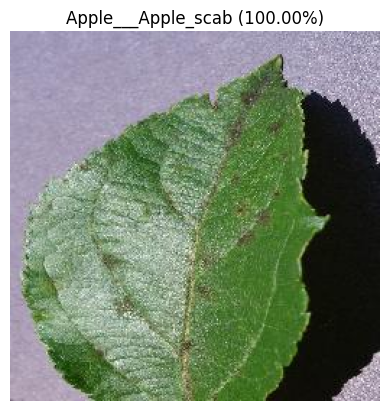

Prediction: Apple___Apple_scab
Confidence: 100.00%


In [ ]:
import torch
import timm
from torchvision import transforms
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Use classes directly from dataset
class_names = full_dataset.classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = timm.create_model("efficientnet_b0", pretrained=False)
model.classifier = nn.Linear(model.classifier.in_features, len(class_names))
model.load_state_dict(torch.load("efficientnet_plant_best.pth", map_location=device))
model.to(device)
model.eval()

# CHANGE THIS PATH
image_path = "/content/dataset/plantvillage dataset/color/Apple___Apple_scab/276ed34e-9987-4b38-b83b-8626504fc204___FREC_Scab 3050.JPG"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probs = F.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probs, 1)

predicted_class = class_names[predicted.item()]
confidence_score = confidence.item() * 100

plt.imshow(image)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence_score:.2f}%)")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", f"{confidence_score:.2f}%")

Pada model eval itu diatur ke mode eval itu karena kita mau predict,kemudian pada img,label kami mengambil gambar secara acak dari data validation untuk menguji model pada data yang belum pernah dilatih.

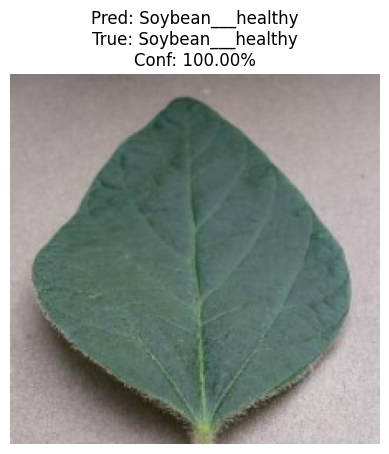

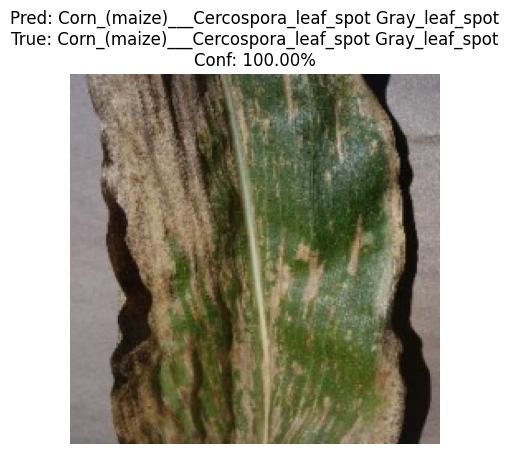

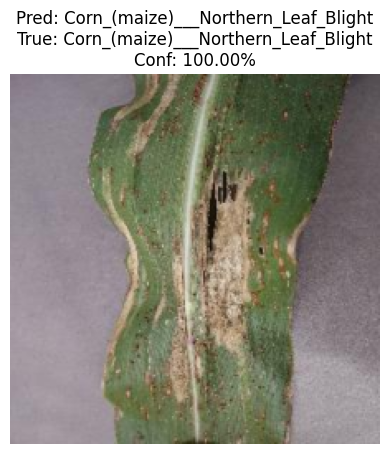

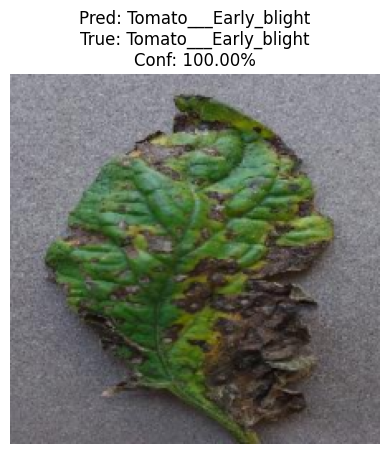

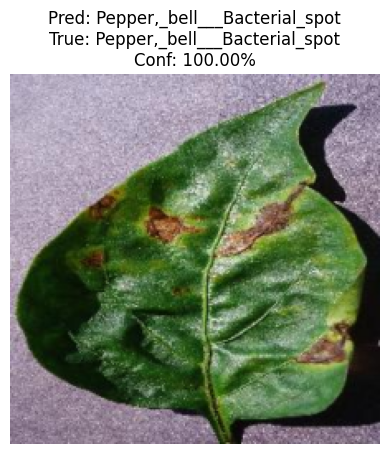

In [ ]:
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()

for i in range(5):
    img, label = val_dataset[random.randint(0, len(val_dataset)-1)]
    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    plt.imshow(img.permute(1,2,0))
    plt.axis("off")
    plt.title(f"Pred: {class_names[pred.item()]}\nTrue: {class_names[label]}\nConf: {conf.item()*100:.2f}%")
    plt.show()

menyimpan list nama kelas (label) ke file .json

In [ ]:
import json

class_names = full_dataset.classes

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("class_names.json saved successfully!")

class_names.json saved successfully!


Mengunduh file dari colab

In [ ]:
from google.colab import files
files.download("/content/class_names.json")
files.download("/content/efficientnet_plant_best.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>